# Debris
Tests and validations.




In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from importlib import reload
from matplotlib import colormaps


import conan 
import conanplot as cp
import constants 
import satDots
import debris
import stuff



### Geometry


Geometry used in some places
- Surface of spherical cap (from $\delta$ to north pole): $S_c = 2\pi r^2 (1 -\sin\delta)$
- Surface of spherical band ($\delta_1 < \delta_2$): $S_b = 2\pi r^2 (\sin\delta_2 - \sin\delta_1)$
- Surface of rectangle with $\Delta\alpha$ [deg]:  $S = S_b (\Delta\alpha / 360 ) = 2\pi r^2 (\sin\delta_2 - \sin\delta_1) (\Delta\alpha / 360 )$

Note: $r = r_{earth} + alt$


In [2]:
# test the surface calculation
reload(stuff)
print("full sphere:",  stuff.surfaceOfSphericalRectangle(   360., -90., 180., 1.)/np.pi, "pi")
print("N hemisphere:", stuff.surfaceOfSphericalRectangle(   360.,   0.,  90., 1.)/np.pi, "pi")
print("W hemisphere:", stuff.surfaceOfSphericalRectangle(   180., -90., 180., 1.)/np.pi, "pi")
print("~1sq deg:",     stuff.surfaceOfSphericalRectangle(     1.,   0.,   1., 180./np.pi), 'sq.deg')


full sphere: 4.0 pi
N hemisphere: 2.0 pi
W hemisphere: 2.0 pi
~1sq deg: 0.9999492312032948 sq.deg


In [3]:
# conversion to volume 
reload(stuff)

print("Earth (510E6km2):",  stuff.surfaceOfSphericalRectangle(   360., -90., 180., constants.earthRadius) )

# Section with altitude=0
print("surfaceOfSection:",             stuff.surfaceOfSection(   360., -90., 180., 0.) )

# Volume with thickness=1
print("VolumeOfPixel   :",                stuff.VolumeOfPixel(   360., -90., 180., 0., 1.) )

Earth (510E6km2): 511207893.3958109
surfaceOfSection: 511207893.3958109
VolumeOfPixel   : 511207893.3958109


### Debris table

Input: table Alt [km], Number density [n/km^3] for sizes  10-i [m], i in [0..7[

The debris input file are tables, one per particle size (10-0 .. 10-6m radius), columns Altitude [km] and particule count [n/km3].

The debris are considered to be uniformly dispersed on sphere shell with radius from alt[i] .. alt[i+1].



Consolidation in a table with columns:

- Alt: altitude [km]
- i:   number density [n/km3], for sizes r in 10-i [m], i in [0..7[

Using albedo $p$ and density $rho$:
- Effective cross section of a grain $a = \pi r^2 p$
- Mass: $m = 4/3 \pi r^3 \rho$

Add columns:

- i_a = i * a : effective cross section density, in [[m2]/[km3]]
- i_m = i * m : mass density [[kg]/[km3]]


Debris, with characteristics of 1 grain (albedo not included):
i: 0, r: 1.0e+00m, a: 6.28e-01m2, m: 2.09e+03kg  
i: 1, r: 1.0e-01m, a: 6.28e-03m2, m: 2.09e+00kg  
i: 2, r: 1.0e-02m, a: 6.28e-05m2, m: 2.09e-03kg  
i: 3, r: 1.0e-03m, a: 6.28e-07m2, m: 2.09e-06kg  
i: 4, r: 1.0e-04m, a: 6.28e-09m2, m: 2.09e-09kg  
i: 5, r: 1.0e-05m, a: 6.28e-11m2, m: 2.09e-12kg  
i: 6, r: 1.0e-06m, a: 6.28e-13m2, m: 2.09e-15kg  
Albedo: 0.2
Density: 500.0 kg/m3



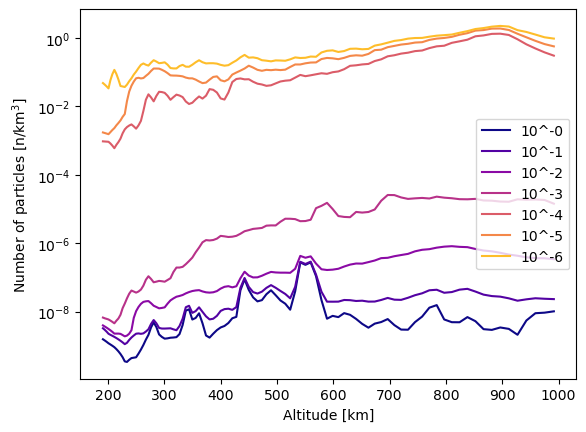

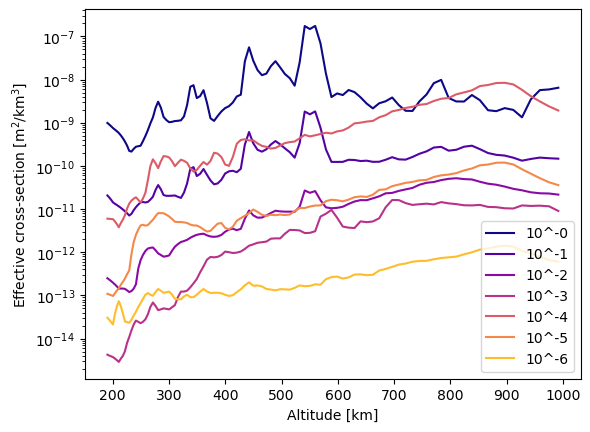

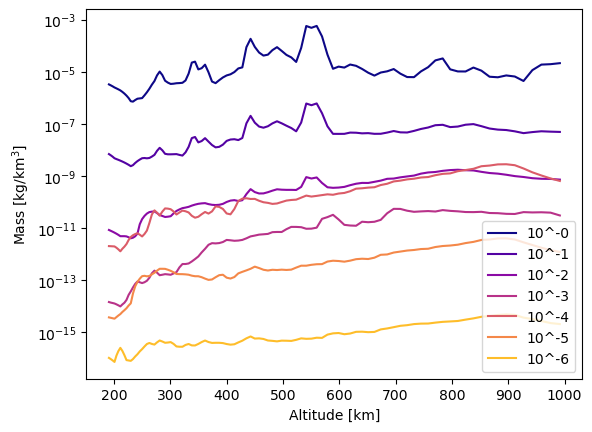

In [4]:
# read in the debris

reload(stuff)
print("Debris, with characteristics of 1 grain (albedo not included):")
D = debris.make_debrisTab()

print("Albedo:", debris.p_albedo)
print("Density:", debris.rho_density, "kg/m3")
print()

stuff.plot_density(D)

### Size distribution over altitude

For each altitude, plot size distribution

#### Consolidation over all the sizes:

- for each shell alt_j, get the thickness of the shell dAlt[j] = alt[j+1] - alt[j] . (The first shell is dropped out, leaving 98 shells).


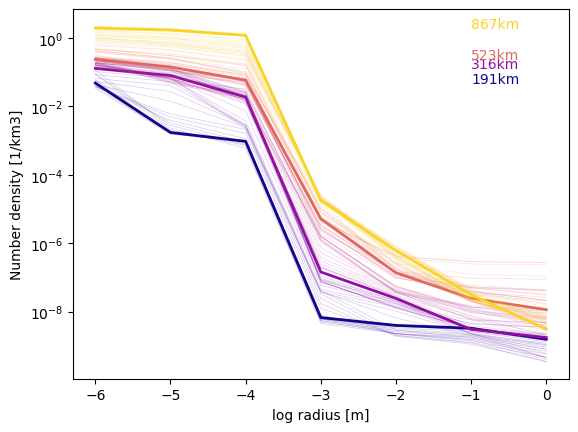

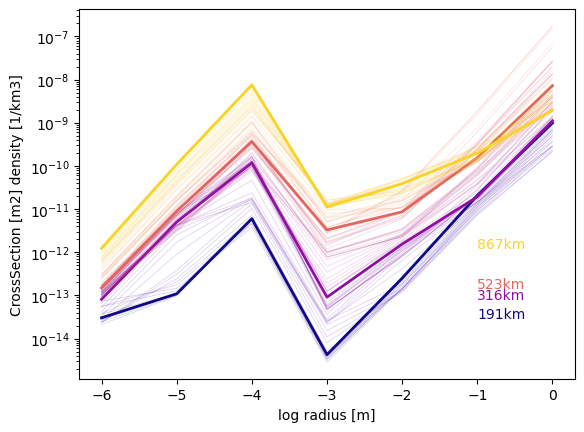

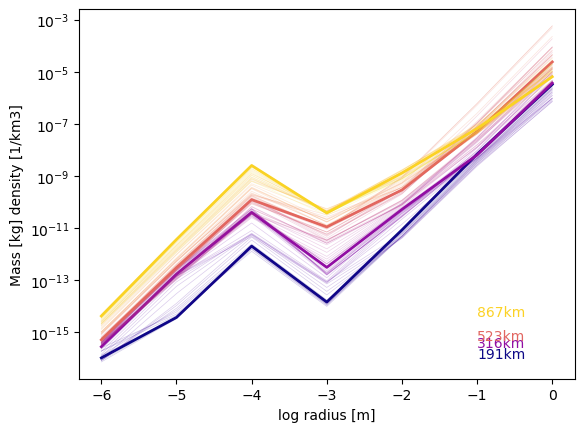

In [5]:
cmap = colormaps['plasma']

def plot_sizeDist(D, mycol="", label="Number"):
    '''D: full table
       mycol: plot quantity {i}{mycol}'''
    plt.figure()
    
    Is = np.arange(0,7)
    for iL, L in enumerate(D):
        grain = [L[f'{i}{mycol}'] for i in Is]
        if iL%30 == 0:
            plt.text(-1,grain[-1], f'{L["alt"]:.0f}km', color=cmap( iL/len(D) ) )
            lw=2
            alpha=1
        else:
            lw=.5
            alpha=0.2
        plt.plot( -Is, grain, color=cmap( iL/len(D) ), linewidth=lw, alpha=alpha)
    plt.yscale('log')
    plt.xlabel('log radius [m]')
    plt.ylabel(label+' density [1/km3]')
    

plot_sizeDist(D)
plot_sizeDist(D,mycol="_a",label="CrossSection [m2]")
plot_sizeDist(D,mycol="_m",label="Mass [kg]")


Convert volume densities (xx/km3) in surface densities (xx/km2) by multiplying by the thickness of the shell (km)

New columns:

- surf_a $= d_{alt} \times \sum_{i=0}^6 i_a $, surf density of cross-section [m2/km2]
- surf_m $= d_{alt} \times \sum_{i=0}^6 i_m $, ... of mass [kg/km2]


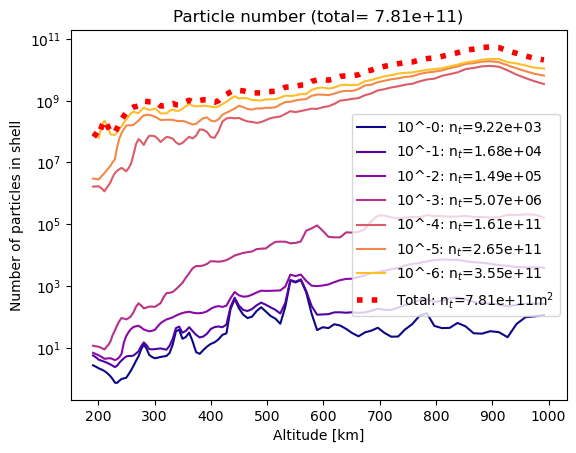

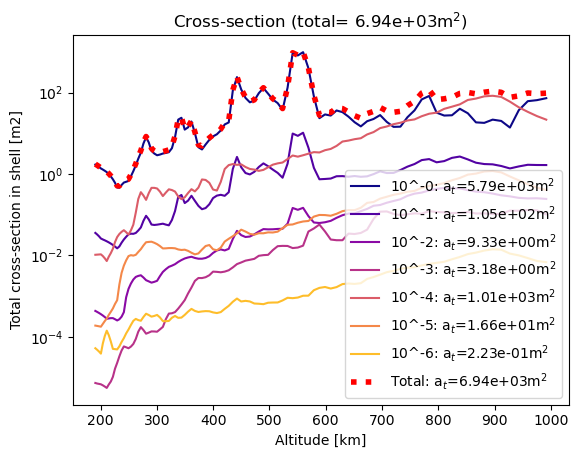

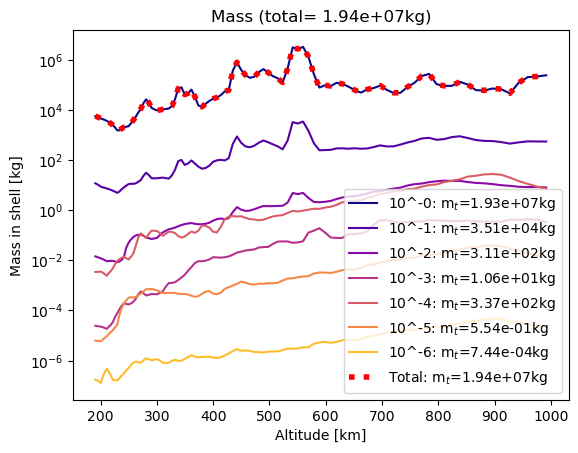

<TableColumns names=('alt','0','0_a','0_m','1','1_a','1_m','2','2_a','2_m','3','3_a','3_m','4','4_a','4_m','5','5_a','5_m','6','6_a','6_m','dAlt','surf_n','surf_a','surf_m','volume','nTOTAL','T0','T1','T2','T3','T4','T5','T6','surface','T_n','T0_a','T1_a','T2_a','T3_a','T4_a','T5_a','T6_a','T_a','T0_m','T1_m','T2_m','T3_m','T4_m','T5_m','T6_m','T_m')>


In [323]:
# integrate over shell

# - consolidated over all size (thick dots), using surf_n, surf_a, surf_m, computed at init. Total in legend
# - each size (color): computed independently, total in title

#=> check the totals

reload(debris)
stuff.get_totalShellSurface(D) # compute D['surface']
stuff.plot_integral(D)

print(D.columns)


## Compare with Kocifaj+21 from NRC95




1.64e+14
1.0000000000000002


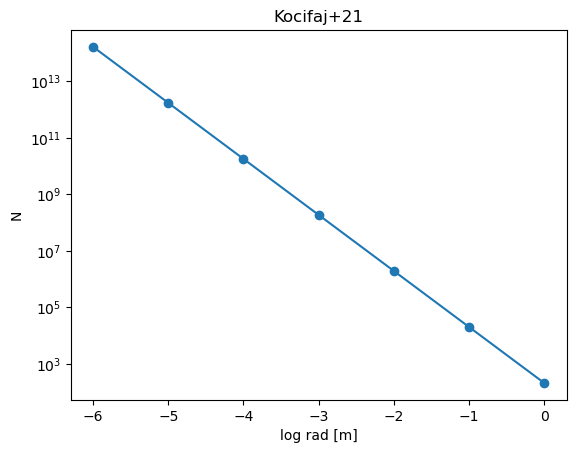

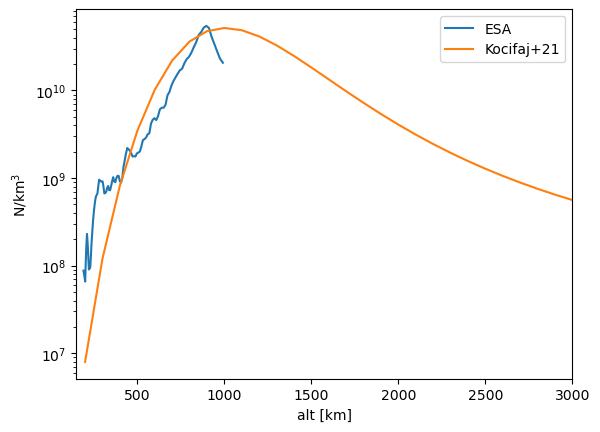

In [338]:
# Radius distribution
def K_radius(logRad):
    a = -1.98
    b = 2.32
    Ntot = 1.64E14/3.67e+09
    return Ntot*10.**(a*logRad-b)  # Kocifaj+21 from NRC95 

logRad = np.arange(-6.,0.1)
N = K_radius(logRad)
plt.figure()
plt.plot(logRad, N, 'o-')

plt.yscale('log')
plt.xlabel('log rad [m]')
plt.ylabel('N')
plt.title('Kocifaj+21')
print(f'{sum(N):.3g}')

# altitude
def K_alt(satAlt):
    '''
    in: 
    - sataAlt: altitude [km]
    
    out: 
    - density [n/km3]
    '''
    logh = np.log10(satAlt)+3. # they work in m

    A= 4.02
    B= 0.60
    C= 7.3
    D= 5.35
    F= 5.3
    m= 5.32
    beta=846.0770656609193 # integral = 1


    expo = A * (logh -D) / (B+ (logh-F)**m ) -C
    return beta*10.**expo

satAlt = np.arange(200., 10001., 100.)
N = K_alt(satAlt)

plt.figure()
plt.plot(D["alt"], D["T_n"], label=f"ESA")
plt.plot(satAlt, N*4e11, label='Kocifaj+21')
plt.legend()

plt.yscale('log')
plt.xlabel('alt [km]')
plt.xlim(150,3000)
plt.ylabel('N/km$^3$')

print(1/sum(N))



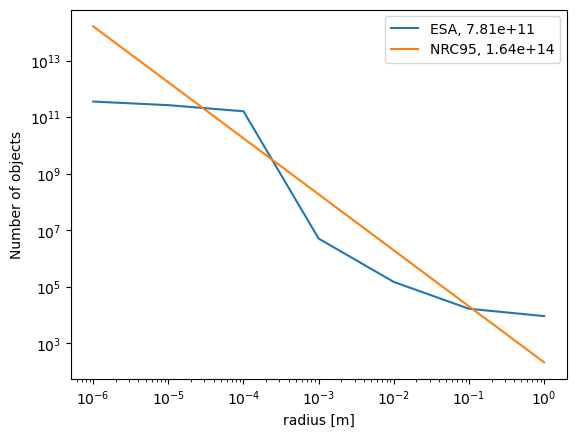

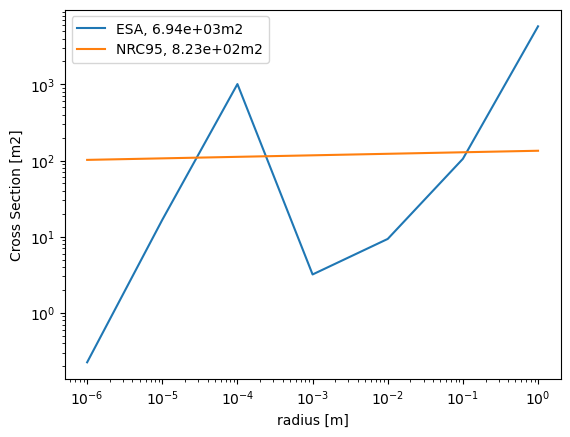

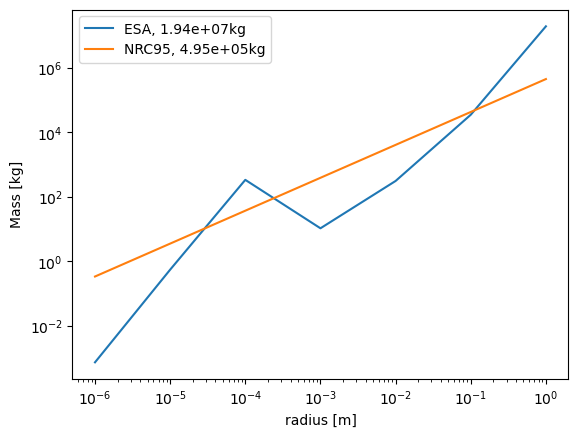

In [ ]:

reload(debris)
logRad = np.arange( 0, 7)   
 
    
r = 10.**(-logRad) # radius in m
a = np.pi * r**2 * debris.p_albedo 
m = 4./3.* np.pi * r**3 * debris.rho_density 
nRad   = 0. * logRad

Kj = K_radius(-logRad) # total number of grains of size i in ALL shells/ Kocifaj

# compute volume of the shells D['volume']
stuff.get_totalShellVolume(D)

# compute total number of grains in each shell
D['nTOTAL'] = 0.
for i in logRad:
    D[f'T{i}']   = D[f'{i}'] * D['volume'] # total number of grains of size i in each shell
    nRad[i] = sum(  D[f'T{i}']  )   # total number of grains of size it in ALL shells / ESA

#N
plt.figure()
plt.plot( r, nRad, label=f'ESA, {sum(nRad):.2e} ')
plt.plot( r, Kj,   label=f'NRC95, {sum(Kj):.2e}' )
plt.yscale('log')
plt.xscale('log')
plt.xlabel('radius [m]')
plt.ylabel('Number of objects')
plt.legend()

#a
plt.figure()
plt.plot( r, nRad*a, label=f'ESA, {sum(nRad*a):.2e}m2 ')
plt.plot( r, Kj*a,  label=f'NRC95, {sum(Kj*a):.2e}m2' )
plt.yscale('log')
plt.xscale('log')
plt.xlabel('radius [m]')
plt.ylabel('Cross Section [m2]')
plt.legend()

# m
plt.figure()
plt.plot( r, nRad*m, label=f'ESA, {sum(nRad*m):.2e}kg ')
plt.plot( r, Kj*m, label=f'NRC95, {sum(Kj*m):.2e}kg' )
plt.yscale('log')
plt.xscale('log')
plt.xlabel('radius [m]')
plt.ylabel('Mass [kg]')
plt.legend()



# Conversion to flux and mag


For EACH of the 99 shells from 200 to 1000km, for each region-of-the-shell corresponding to a range in Azimuth and Elevation:

$S$ surface of the region of the shell, in km2

$s_a$ surface density of cross-section in the region, in m2/km2

$a = S . s_a$ (including albedo) is the cross-section, in m2, 


$m_{sun}$: magnitude of the Sun from Earth

$f_{sun} = 10^{-0.4 m_{sun}}$ flux of the sun in arbitrary units

$au$: 1astron unit, in m

$\Delta$ distance observer - region of the shell, in km.

Flux from cross-section:  $f = S.(a[m])^2 .  f_{sun}/ (\Delta[km])^2 . 10^{-6} $

Note:

- $10^{-6}$: convert $a^2$ [m2] to same unit as $\Delta^2$ [km2]
- cross section already includes the albedo ( $a^2 = p r^2$ )

$f$ is the total flux from the region of the shell.

$f/ (3600)^2$ is the flux /arcsec2 seen from the ground
(the regions of the shell are poked every degree; the size of the region-of-the shell is accurately computed, and normalized (thanks to the use of surface density). 


The fluxes/sqarcsec from each shell are summed in each Azimuth-Elevation region.

The total fluxes/sqarcsec are converted to mag/sqarcsec: $mag = -2.5 \log f$, and plotted.



In [165]:
print("mag_sun", constants.magSun)
print("flux_sun", f'{debris.fluxSun:.2e} funits')

mag_sun -26.75
flux_sun 5.01e+10 funits


### Verification: magnitude of the debris

- one grain: cross section = $p r^2$
- Distance: at zenith=$h$ altitude 

Magnitude $M = M_{sun} -2.5\log( p r^2) + 5\log(h)$


(40.0, 0.0)

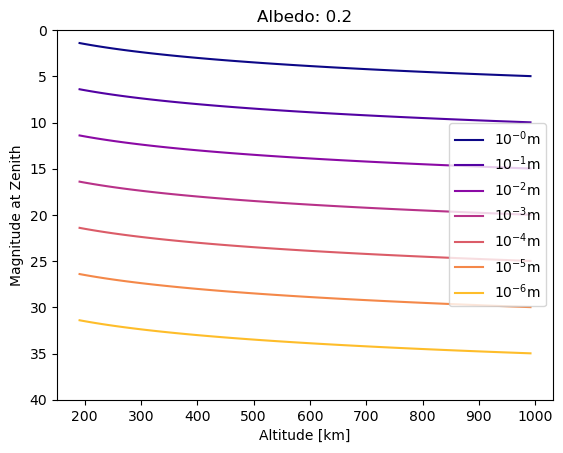

In [244]:
p = 0.2
def mag(r, Delta):
    '''r [m], h [km]'''
    return constants.magSun -2.5*np.log10( p*r**2 ) +5.*np.log10(Delta*1000.)

for i in np.arange(0,7):
    color=cmap( i/7. )
    plt.plot(D["alt"],mag( 10.**-i, D['alt']) , color=color, label=f'$10^{{ -{i} }}$m')
plt.legend()
plt.xlabel("Altitude [km]")
plt.ylabel("Magnitude at Zenith")
plt.title(f'Albedo: {p}')
plt.ylim(40.,0.)

### Trailing of the object:

Effective Mag: $M_{eff} = M - 2.5 \log\frac{r}{\omega t}$

with: $r$ resolution, $t$ exposure time, $\omega$ apparent angular velocity (same units as r and t)

$\omega$ is computed in ConAn.

Text(0, 0.5, 'Apparent angular velocity [deg/s]')

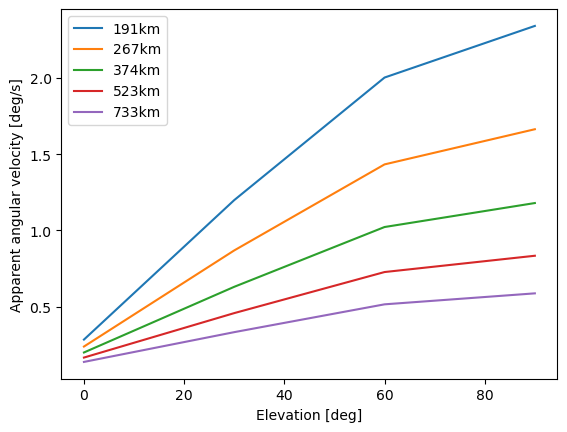

In [116]:
# apparent angular velocity

reload(conan)
mEl = np.arange(0.,91.,30.)
mAz = mEl*0.
AzEl = np.array([mAz,mEl])


satInc = 90.
obsLatitude = 0.

for satAlt in D['alt'][::20]:
    alpha, delta, Delta, costheta = conan.AltAz2Delta(obsLatitude,satAlt,AzEl)
    omega = conan.AzEl2Vel(alpha, delta, Delta, obsLatitude,satInc,satAlt)
    plt.plot(mEl, omega, label=f'{satAlt:.0f}km')
    
plt.legend()
plt.xlabel("Elevation [deg]")
plt.ylabel('Apparent angular velocity [deg/s]')

### Detectability:
    
If $M_{eff} < M_{lim}$: the debris is detected as an individual object;

else: it contributes to the background.

- For naked eye: expt.5s, resol=1arcmin=0.16deg, M_lim=7
- For all_sky cam: expt=120s, resol=0.02 deg, M_lim=12

From the plots below:

- for naked eye: debris 10^0 are visible;
- for all-sky: debris 10^0 and -1 are visible;


    

(30.0, 0.0)

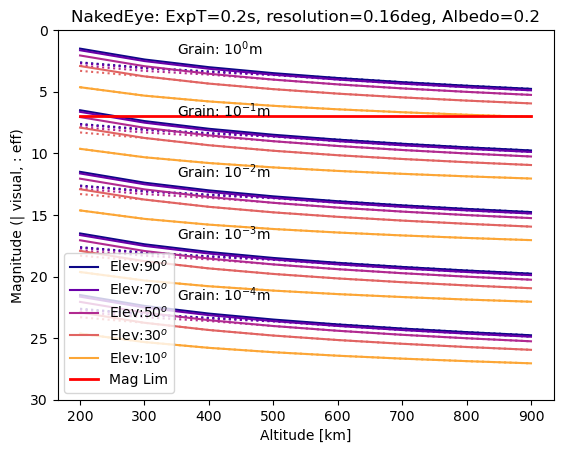

In [319]:
# effective mag:
reload(conan)


satInc = 90.
obsLatitude = 0.

if 1: #EYE
    title = 'NakedEye'
    expt = .2 #[sec]
    resol = .16 #[deg]
    magLim = 7.
else: #allSky
    title = 'AllSkyCam'
    expt = 120 #[sec]
    resol = .02 #[deg]
    magLim = 12.

    
satAlt = np.arange( 200.,1000.,100.)

Els = np.arange(90.,0.,-20)
for i in np.arange(0,5): #size
    plt.text(350.,2+5*i,f'Grain: $10^{{{-i}}}$m')
    
    for iEl, El in enumerate(Els):
        AzEl = np.array([[0.],[El]]) # Zenith
        alpha, delta, Delta, costheta = conan.AltAz2Delta(obsLatitude,satAlt,AzEl)
        omega = conan.AzEl2Vel(alpha, delta, Delta, obsLatitude,satInc,satAlt)

        radius = 10.**-i
        color=cmap( iEl/len(Els) )

        m = mag( radius, Delta) 
        trail =  -2.5*np.log10( resol / (omega*expt))
        trail[ trail < 0.] = 0.
        mr = m + trail

        if i == 0:
            plt.plot(satAlt, m , color=color, label=f'Elev:{El:.0f}$^o$')
        else:
            plt.plot(satAlt, m , color=color)
            
        plt.plot(satAlt, mr , linestyle=":",  color=color)
        
        

plt.plot(satAlt, satAlt*0+magLim, "r", linewidth=2, label="Mag Lim" )
plt.legend()
plt.xlabel("Altitude [km]")
plt.ylabel("Magnitude (| visual, : eff)")
plt.title(f'{title}: ExpT={expt}s, resolution={resol}deg, Albedo={p}')
plt.ylim(30.,0.)


### Number of grains per sq.deg

A square cone pointing at the sky, from the observatory, side= step=1deg, area on sky: step$^2$

The cone intercepts the shell with radius $r = r_{earth} + a$, a altitude [km]

Distance observer-shell: $\Delta$ [km], computed by conan.AltAz2Delta.

The angle between the line-of-sight and the shell is $\theta$, computed by conan.AltAz2Delta.

Surface of the shell in the cone: $S = \Delta . s^2 / \cos(\theta)$ [km2]


Text(0.5, 1.0, ' (...: not corrected; --- corrected for cos$\theta$)')

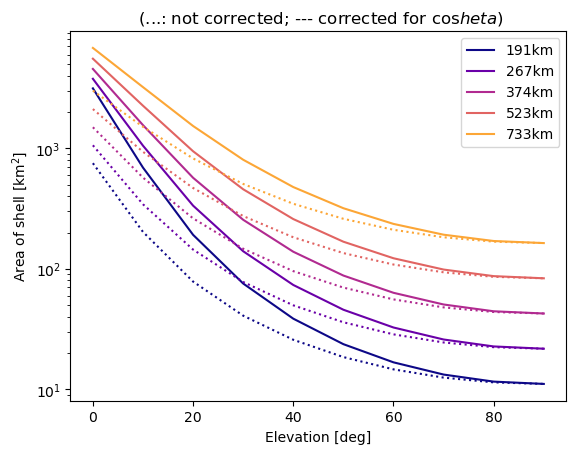

In [320]:
# Surface of the shell corresponding to 1sq.deg on sky
reload(conan)
mEl = np.arange(0.,91.,10.)
mAz = mEl*0.
AzEl = np.array([mAz,mEl])
step = 1. #[deg]

satAlt = 550. # [km]
obsLatitude = 0.
satAlts = D['alt'][::20]

for ia, satAlt in enumerate(satAlts):
    
    color=cmap( ia/len(satAlts) )

    
    alpha, delta, Delta, costheta = conan.AltAz2Delta(obsLatitude,satAlt,AzEl)
    surface = (Delta * np.radians(step))**2 #
    plt.plot(mEl, surface, ':',color=color)
    plt.plot(mEl, surface/costheta, color=color,  label=f'{satAlt:.0f}km')
    
plt.legend()
plt.yscale('log')
plt.xlabel("Elevation [deg]")
plt.ylabel('Area of shell [km$^2$]')
plt.title(' (...: not corrected; --- corrected for cos$\theta$)')

in ConAn: python ~/Documents/ESO/E2E/SatelliteConstellations/SIMULATIONS/ConAn/DEVELOPMENT/SatConAnalytic/obsSkyDebris.py   -M surface
    
<img src="test_surface.png">

### Number of grain particles

 = number surface density [n/km2] * area of shell in cone [km2].
 
 = number volume density [n/km3] * thickness of shell [km]  * area of shell in cone [km2]
 
 
 "Pixel" on sky:
 - 1sq.deg: generic for comparison
 - 1sq.arcmin: resolution of human eye, or of all-sky cameras
 - 1sq.arcsec: resolution of an imager
 
 

Text(0, 0.5, 'Number of grains in pixel')

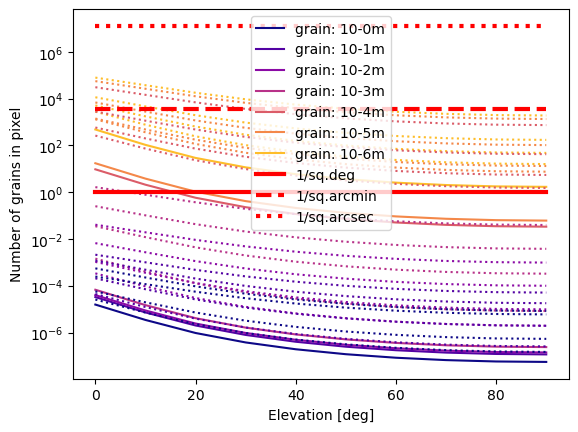

In [303]:
# number of grains

reload(conan)
mEl = np.arange(0.,91.,10.)
mAz = mEl*0.
AzEl = np.array([mAz,mEl])
step = 1. #[deg]

satAlt = 550. # [km]
obsLatitude = 0.
subD = D[::20]

for ia in np.arange(len(subD)): # scan altitudes
    alpha, delta, Delta, costheta = conan.AltAz2Delta(obsLatitude,subD['alt'][ia],AzEl)
    surface = (Delta * np.radians(step))**2/costheta 
    
    
    for ir in  np.arange(0,7): # scan debris sizes
        color=cmap( ir/7. )        

        nDebris = surface * subD[f'{ir}'][ia] * subD['dAlt'][ia]
        if ia == 0:
            plt.plot(mEl, nDebris, color=color,  label=f'grain: 10-{ir}m')
        else:
            plt.plot(mEl, nDebris,":" , color=color)
    
    
plt.plot( mEl, mEl*0+1, 'r-', label='1/sq.deg', linewidth=3)
plt.plot( mEl, mEl*0+60**2, 'r--', label='1/sq.arcmin', linewidth=3)
plt.plot( mEl, mEl*0+3600**2, 'r:', label='1/sq.arcsec', linewidth=3)

plt.legend()
plt.yscale('log')
plt.xlabel("Elevation [deg]")
plt.ylabel('Number of grains in pixel')


python obsSkyDebris.py   -M debrisCount --lrad 0 3 
<img src='test_count03.png'>


python obsSkyDebris.py   -M debrisCount --lrad 4 6
<img src='test_count46.png'>


---

# Sky Brightness

Canonical value for dark sky: V = 22/sqarc  - eg in "Brightness of the night sky over La Palma C.R Benn a, S.L Ellison".

Dependency with airmass:
see "TechNote No 115 La Palma night-sky brightness. "

$\Delta m = -2.5 \log ( f . \zeta + (1-f) )$

With $\zeta$ airmass (! infinite at horizon), $f$ fraction of sky background coming from airglow; typical values ~ 0.7

For validation, they mention: Dmag = .04, .11, .20, .34, .54 at ZD= 20, 30, 40, 50, 60

    

Text(0, 0.5, '$\\Delta$ mag')

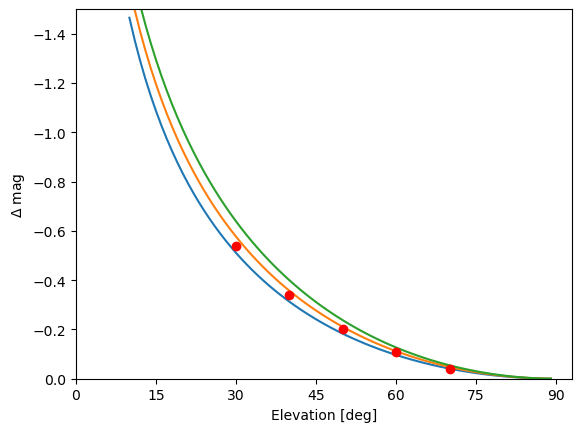

In [315]:
reload(debris)
BeEl = -np.array([  .04, .11, .20, .34, .54 ])
ZD = np.array([20., 30., 40., 50., 60.])
El = 90.-ZD

Els = np.arange(10.,90.)
for f in [0.6, 0.7, 0.8]:
    plt.plot(Els,   debris.modelSkyBrightness(Els , f=f, mag=0) )
plt.plot(El, BeEl, 'or', zorder=100)

plt.ylim(0.,-1.5)
plt.xticks(np.arange(0.,91,15.))
plt.xlabel("Elevation [deg]")
plt.ylabel(r"$\Delta$ mag")

### Twilight value:

- day: SunEl>0: mag=8
- night: SunEl<-18: mag=22

Stupid linear trend in between.

Confirm Patat 2006 A&A : OK


Text(0, 0.5, 'Sky brightness at zenith [mag/sqarcs]')

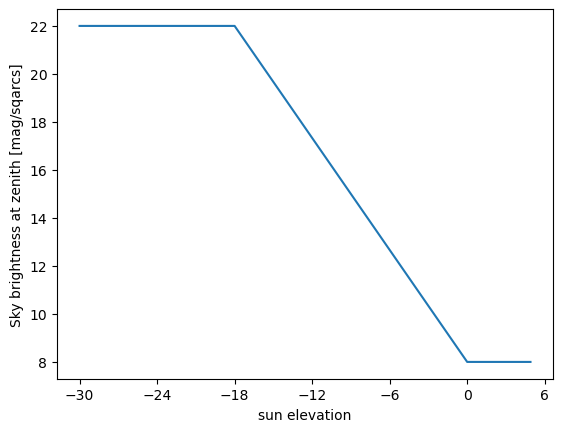

In [7]:
reload(debris)
sunEl = np.arange(-30, 5,.1)
mag = 0*sunEl
for i in np.arange(len(sunEl)):
    mag[i] = debris.modelTwilight(sunEl[i])
    
plt.plot(sunEl, mag)
plt.xticks(np.arange(-30.,7.,6.))
plt.xlabel('sun elevation')
plt.ylabel('Sky brightness at zenith [mag/sqarcs]')

python obsSkyDebris.py   -M skyMag

![skyBrightness](test_skyBrightness.png)